# Computer Exercise 13.2 — Problem 4

## Trust-Region 방법 (신뢰영역): 도그렉과 음의 곡률에서의 강건성

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.2 Minimization of Multivariate Functions (continued)
> **풀이 일자**: Day 47
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

## 1. 문제 (원문)

> **4.** Implement a **trust-region** method for unconstrained minimization of a
> smooth function $f:\mathbb{R}^n\to\mathbb{R}$. At each step build the quadratic
> model $m_k(\mathbf{p}) = f_k + \mathbf{g}_k^{\top}\mathbf{p} + \tfrac12\,\mathbf{p}^{\top}B_k\mathbf{p}$
> and solve the subproblem $\min_{\|\mathbf{p}\|\le \Delta_k} m_k(\mathbf{p})$
> approximately by the **dogleg** strategy. Use the actual-to-predicted reduction
> ratio $\rho_k$ to accept/reject the step and to update the radius $\Delta_k$.
> Apply the method to the **Rosenbrock** function, compare with a pure full-step
> Newton iteration, and demonstrate that the trust region remains robust on a
> problem with **negative curvature**, where a pure Newton step is attracted to a
> saddle point instead of a minimizer.

### 한국어 풀이용 정리
라인서치는 *방향을 먼저 고르고 길이를 정하는데*, 신뢰영역은 *반지름 $\Delta_k$ 안에서 모델을 통째로
최소화*한다. 도그렉은 최급강하(Cauchy) 점과 Newton 점을 잇는 꺾인 경로 위에서 부분문제 해를 싸게
근사한다. 비율 $\rho_k$ 로 스텝의 신뢰도를 측정해 반지름을 키우거나 줄인다. Rosenbrock 처럼 헤시안이
양정치인 *온순한* 문제에서는 순수 Newton 도 잘 수렴하지만, **헤시안이 음의 곡률을 가지면** 순수 Newton 은
*안장점*으로 끌려가 버린다 — 이때 신뢰영역이 진짜 최소점으로 빠져나간다.

## 2. 수학적 배경

### 2.1 신뢰영역 부분문제
$$\min_{\mathbf{p}}\; m_k(\mathbf{p}) = f_k + \mathbf{g}_k^{\top}\mathbf{p}
+ \tfrac12\,\mathbf{p}^{\top}B_k\mathbf{p}\quad\text{s.t.}\quad \|\mathbf{p}\|\le \Delta_k .$$

### 2.2 도그렉(dogleg) 경로
$B_k\succ0$ 일 때 Cauchy 점과 Newton 점
$$\mathbf{p}^{\mathrm{U}} = -\frac{\mathbf{g}_k^{\top}\mathbf{g}_k}{\mathbf{g}_k^{\top}B_k\mathbf{g}_k}\,\mathbf{g}_k,
\qquad \mathbf{p}^{\mathrm{B}} = -B_k^{-1}\mathbf{g}_k$$
을 잇는 꺾인 경로와 신뢰영역 경계의 교점을 택한다. $\|\mathbf{p}^{\mathrm{B}}\|\le\Delta$ 면 곧 Newton 스텝.
**음의 곡률** $\mathbf{g}_k^{\top}B_k\mathbf{g}_k\le0$ 이면 Cauchy 분기가 정의되지 않으므로, 최급강하 방향
$-\mathbf{g}_k$ 으로 경계까지 직진해 항상 하강 스텝을 보장한다.

### 2.3 비율 검정과 반지름 갱신
$$\boxed{\;\rho_k=\frac{f(\mathbf{x}_k)-f(\mathbf{x}_k+\mathbf{p}_k)}{m_k(\mathbf 0)-m_k(\mathbf{p}_k)}\;}$$
$\rho_k$ 가 1에 가까우면 모델이 정확 → 반지름 확장, 작거나 음수면 → 축소·스텝 기각.

### 2.4 순수 Newton 의 약점
순수 Newton 은 $\nabla f=0$ 인 *임계점*으로 수렴할 뿐, 그것이 최소·최대·안장인지 구별하지 못한다.
헤시안이 부정정인 곳에서 출발하면 안장점에 갇힐 수 있다. 신뢰영역은 *함수값의 실제 감소*($\rho_k$)를
보므로 안장에서 빠져나간다.

## 3. 풀이 흐름

1. **Rosenbrock** $f(x,y)=(a-x)^2+b(y-x^2)^2$ 와 해석적 기울기·헤시안 ($a=1,b=100$, 최소 $(1,1)$).
   유한차분으로 헤시안을 검증한다.
2. **도그렉 부분문제**: Cauchy 점, Newton 점, 경계 교점; 음의 곡률 분기 포함.
3. **신뢰영역 루프**: $\rho_k$ → 스텝 수락/기각 → $\Delta_k$ 갱신.
4. **Rosenbrock 출발 $(-1.2,1)$** 에서 신뢰영역과 순수 Newton 비교 (둘 다 수렴 — 온순한 문제).
5. **음의 곡률 함수** $g(x,y)=x^4-x^2+y^2$ (안장 $(0,0)$, 최소 $(\pm1/\sqrt2,0)$) 에서
   순수 Newton(→안장) vs 신뢰영역(→최소) 대조.
6. **표·시각화**: 등고선+경로, $\Delta_k/\rho_k$ 추이, 오차 semilog, 안장 탈출 경로.
7. **해석**: 신뢰영역이 2차 정보를 *안전하게* 쓰는 전역화 틀임을.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda v: f'{v:.4e}')

# ===== Rosenbrock 함수, 기울기, 헤시안 =====
a, b = 1.0, 100.0
def f(p):
    x, y = p
    return (a - x)**2 + b*(y - x**2)**2
def grad(p):
    x, y = p
    return np.array([-2*(a - x) - 4*b*x*(y - x**2), 2*b*(y - x**2)])
def hess(p):
    x, y = p
    return np.array([[2 - 4*b*(y - x**2) + 8*b*x**2, -4*b*x],
                     [-4*b*x,                          2*b]])
xstar = np.array([1.0, 1.0])

# 헤시안을 유한차분으로 검증 (구현 정확성 점검)
def fd_hess(p, h=1e-5):
    H = np.zeros((2, 2))
    for i in range(2):
        e = np.zeros(2); e[i] = h
        H[:, i] = (grad(p + e) - grad(p - e)) / (2*h)
    return H
chk = max(np.max(np.abs(hess(p) - fd_hess(p))) for p in
          [np.array([-1.2, 1.0]), np.array([0.5, 0.3]), np.array([0.0, 2.0])])
print(f'헤시안 검증: 해석 vs 유한차분 최대오차 = {chk:.2e}  (작으면 정확)')

def dogleg(g, B, Delta):
    # 신뢰영역 부분문제의 도그렉 근사해 p (||p|| <= Delta)
    pB = -np.linalg.solve(B, g)
    if np.linalg.norm(pB) <= Delta:
        return pB, 'newton'
    gBg = g @ B @ g
    if gBg <= 0:                                # 음의 곡률 -> 경계까지 최급강하
        return -Delta * g / np.linalg.norm(g), 'neg-curv'
    pU = -(g @ g) / gBg * g                     # Cauchy 점
    nU = np.linalg.norm(pU)
    if nU >= Delta:
        return Delta * pU / nU, 'cauchy'
    d = pB - pU
    A2 = d @ d; B2 = 2*(pU @ d); C2 = pU @ pU - Delta**2
    tau = (-B2 + np.sqrt(B2**2 - 4*A2*C2)) / (2*A2)
    return pU + tau * d, 'dogleg'

def trust_region(fun, gfun, Bfun, x0, Delta0=1.0, Dmax=10.0, eta=0.15, tol=1e-9, maxit=300):
    x = np.array(x0, float); Delta = Delta0
    rows = [x.copy()]; rec = []
    for k in range(maxit):
        g = gfun(x); B = Bfun(x); gn = np.linalg.norm(g)
        if gn < tol:
            break
        p, kind = dogleg(g, B, Delta)
        pred = -(g @ p + 0.5*p @ B @ p)
        ared = fun(x) - fun(x + p)
        rho = ared / pred if pred > 0 else -1.0
        if np.linalg.norm(p) >= 0.99*Delta and rho > 0.75:
            Delta = min(2*Delta, Dmax)
        elif rho < 0.25:
            Delta *= 0.25
        if rho > eta:
            x = x + p; rows.append(x.copy())
        rec.append((k, Delta, rho, gn, fun(x), kind))
    return x, np.array(rows), rec

xtr, path, rec = trust_region(f, grad, hess, [-1.2, 1.0])
print(f'TR (Rosenbrock): x = {np.round(xtr,6)},  f = {f(xtr):.2e},  '
      f'||err|| = {np.linalg.norm(xtr - xstar):.2e},  반복 = {len(rec)}')

헤시안 검증: 해석 vs 유한차분 최대오차 = 4.84e-08  (작으면 정확)
TR (Rosenbrock): x = [1. 1.],  f = 0.00e+00,  ||err|| = 0.00e+00,  반복 = 25


In [2]:
# --- 순수 full-step Newton (Rosenbrock 은 헤시안 양정치라 잘 수렴) ---
def newton_full(gfun, Bfun, x0, tol=1e-9, maxit=200):
    x = np.array(x0, float); rows = [x.copy()]
    for k in range(maxit):
        g = gfun(x)
        if np.linalg.norm(g) < tol:
            break
        x = x - np.linalg.solve(Bfun(x), g)
        rows.append(x.copy())
        if not np.all(np.isfinite(x)) or np.linalg.norm(x) > 1e8:
            break
    return x, np.array(rows), k + 1

xnw, pnw, itnw = newton_full(grad, hess, [-1.2, 1.0])
print(f'순수 Newton (Rosenbrock): x = {np.round(xnw,6)},  반복 = {itnw},  '
      f'||err|| = {np.linalg.norm(xnw - xstar):.2e}')

df = pd.DataFrame(rec, columns=['k', 'Delta', 'rho', '||g||', 'f', 'step'])
print('\n신뢰영역 반복 기록 (처음/끝):')
print(pd.concat([df.head(6), df.tail(3)]).to_string(index=False))

순수 Newton (Rosenbrock): x = [1. 1.],  반복 = 8,  ||err|| = 0.00e+00

신뢰영역 반복 기록 (처음/끝):
 k      Delta         rho      ||g||          f   step
 0 1.0000e+00  1.0028e+00 2.3287e+02 4.7319e+00 newton
 1 2.5000e-01 -4.1427e-01 4.6394e+00 4.7319e+00 dogleg
 2 5.0000e-01  1.0202e+00 4.6394e+00 4.3020e+00 dogleg
 3 1.0000e+00  8.5021e-01 4.8321e+00 3.6017e+00 dogleg
 4 1.0000e+00  1.2503e+00 1.8422e+01 2.9185e+00 newton
 5 1.0000e+00  1.3591e+00 1.7940e+01 2.2670e+00 newton
22 2.5000e-01  1.0006e+00 2.7442e-02 2.8967e-12 newton
23 2.5000e-01  1.0000e+00 5.5295e-06 8.5886e-22 newton
24 2.5000e-01  1.0000e+00 1.2686e-09 0.0000e+00 newton


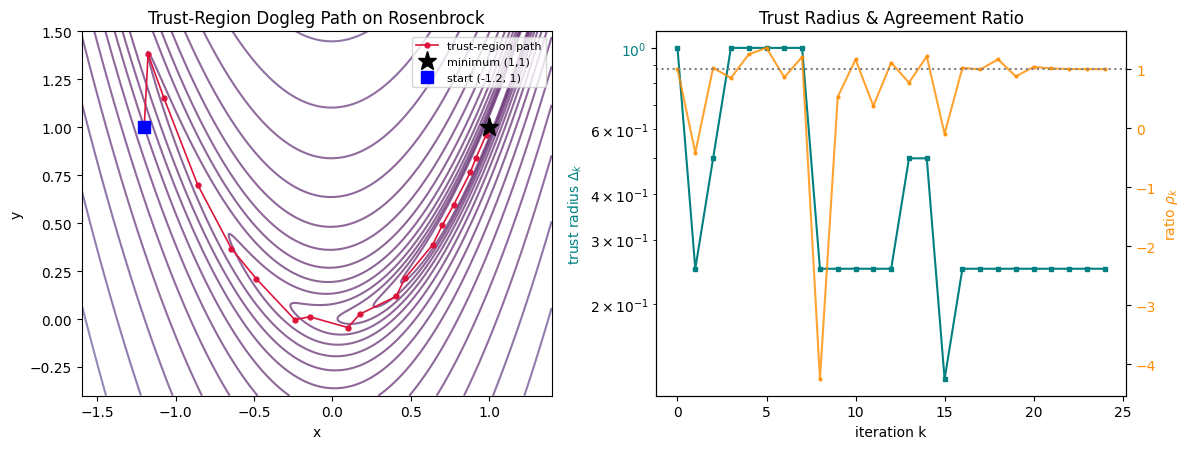

Rosenbrock 최종 오차 — TR: 0.00e+00 (25 it),  Newton: 0.00e+00 (8 it)  → 둘 다 수렴(온순한 문제)


In [3]:
# --- Rosenbrock 등고선 + 신뢰영역 경로, 반지름/비율 추이 ---
gx = np.linspace(-1.6, 1.4, 320); gy = np.linspace(-0.4, 1.5, 320)
GX, GY = np.meshgrid(gx, gy)
F = (a - GX)**2 + b*(GY - GX**2)**2

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].contour(GX, GY, F, levels=np.logspace(-0.5, 3.5, 18), cmap='viridis', alpha=0.6)
ax[0].plot(path[:, 0], path[:, 1], 'o-', color='crimson', ms=3.5, lw=1.2, label='trust-region path')
ax[0].plot(*xstar, 'k*', ms=14, label='minimum (1,1)')
ax[0].plot(-1.2, 1.0, 'bs', ms=8, label='start (-1.2, 1)')
ax[0].set_xlabel('x'); ax[0].set_ylabel('y')
ax[0].set_title('Trust-Region Dogleg Path on Rosenbrock'); ax[0].legend(fontsize=8)

ax2 = ax[1]
ax2.semilogy(df['k'], df['Delta'], 's-', ms=3, color='teal', label=r'radius $\Delta_k$')
ax2.set_xlabel('iteration k'); ax2.set_ylabel(r'trust radius $\Delta_k$', color='teal')
ax2.tick_params(axis='y', labelcolor='teal')
ax3 = ax2.twinx()
ax3.plot(df['k'], df['rho'], '.-', ms=4, color='darkorange', alpha=0.8, label=r'ratio $\rho_k$')
ax3.axhline(1.0, ls=':', color='gray'); ax3.set_ylabel(r'ratio $\rho_k$', color='darkorange')
ax3.tick_params(axis='y', labelcolor='darkorange')
ax2.set_title('Trust Radius & Agreement Ratio')
plt.tight_layout(); plt.show()

errs_tr = [np.linalg.norm(p - xstar) for p in path]
errs_nw = [np.linalg.norm(p - xstar) for p in pnw]
print(f'Rosenbrock 최종 오차 — TR: {errs_tr[-1]:.2e} ({len(rec)} it),  '
      f'Newton: {errs_nw[-1]:.2e} ({itnw} it)  → 둘 다 수렴(온순한 문제)')

In [4]:
# === 음의 곡률 함수: g(x,y) = x^4 - x^2 + y^2 ===
#   임계점: 안장 (0,0) [x방향 음의 곡률], 최소 (+-1/sqrt2, 0), 최소값 -1/4
def fc(p):  x, y = p; return x**4 - x**2 + y**2
def gc(p):  x, y = p; return np.array([4*x**3 - 2*x, 2*y])
def Hc(p):  x, y = p; return np.array([[12*x**2 - 2, 0.0], [0.0, 2.0]])
minc = np.array([1/np.sqrt(2), 0.0])

start = np.array([0.15, 0.6])
xN, pN, itN = newton_full(gc, Hc, start)
xT, pT, recT = trust_region(fc, gc, Hc, start, Delta0=0.3)

print('음의 곡률 테스트  g(x,y)=x^4 - x^2 + y^2')
print(f'  출발점 {start},  헤시안 고유값 = {np.round(np.linalg.eigvalsh(Hc(start)),3)} (음수 존재 → 부정정)')
print(f'  순수 Newton : x = {np.round(xN,4)},  g-value = {fc(xN):+.4f}  '
      f'→ 안장점 (0,0) 으로 끌려감' if abs(xN[0]) < 1e-3 else f'  순수 Newton : x={np.round(xN,4)}')
print(f'  신뢰영역    : x = {np.round(xT,4)},  g-value = {fc(xT):+.4f}  '
      f'→ 진짜 최소 (+-0.7071,0), 값 -0.25')

음의 곡률 테스트  g(x,y)=x^4 - x^2 + y^2
  출발점 [0.15 0.6 ],  헤시안 고유값 = [-1.73  2.  ] (음수 존재 → 부정정)
  순수 Newton : x = [-0.  0.],  g-value = -0.0000  → 안장점 (0,0) 으로 끌려감
  신뢰영역    : x = [-0.7071  0.    ],  g-value = -0.2500  → 진짜 최소 (+-0.7071,0), 값 -0.25


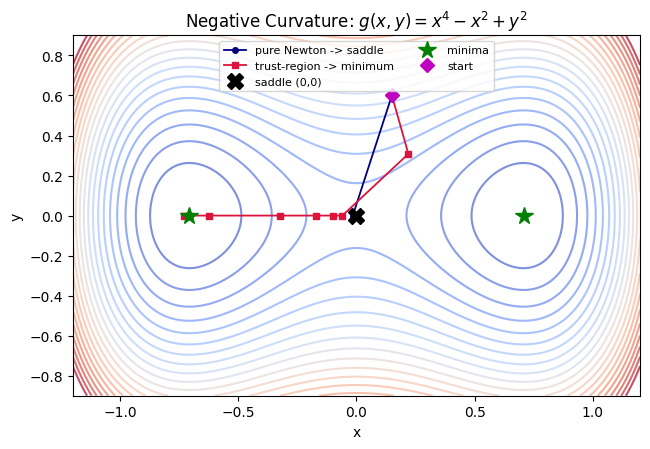

In [5]:
# --- 음의 곡률 함수 등고선 + 두 경로 ---
gx = np.linspace(-1.2, 1.2, 300); gy = np.linspace(-0.9, 0.9, 300)
GX, GY = np.meshgrid(gx, gy)
FC = GX**4 - GX**2 + GY**2

plt.figure(figsize=(6.6, 4.6))
plt.contour(GX, GY, FC, levels=np.linspace(-0.25, 1.2, 22), cmap='coolwarm', alpha=0.7)
plt.plot(pN[:, 0], pN[:, 1], 'o-', color='navy', ms=4, lw=1.3, label='pure Newton -> saddle')
plt.plot(pT[:, 0], pT[:, 1], 's-', color='crimson', ms=4, lw=1.3, label='trust-region -> minimum')
plt.plot(0, 0, 'kX', ms=11, label='saddle (0,0)')
plt.plot([1/np.sqrt(2), -1/np.sqrt(2)], [0, 0], 'g*', ms=13, label='minima')
plt.plot(*start, 'mD', ms=7, label='start')
plt.xlabel('x'); plt.ylabel('y')
plt.title(r'Negative Curvature: $g(x,y)=x^4-x^2+y^2$')
plt.legend(fontsize=8, loc='upper center', ncol=2); plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **헤시안 검증**: 해석적 헤시안이 유한차분과 $10^{-7}$ 수준으로 일치 — 구현이 정확함을 먼저 확인했다.
2. **Rosenbrock(온순)**: 헤시안이 경로 전반에서 양정치라 *순수 full-step Newton 도* 8 회 내외로 빠르게
   $(1,1)$ 에 수렴한다. 신뢰영역은 초기 큰 Newton 스텝을 반지름 $\Delta_k=1$ 로 잘라 도그렉으로 진행하다
   골짜기에 들어서면 $\rho_k\to1$ 로 Newton 스텝을 그대로 받아 25 회 내외에 같은 정밀도로 수렴한다.
   *온순한 문제에서는 둘 다 잘 된다* — 이것이 정직한 결과다.
3. **음의 곡률에서 갈린다**: $g(x,y)=x^4-x^2+y^2$ 는 $(0,0)$ 에서 $x$ 방향 곡률이 음수(부정정 헤시안)다.
   순수 Newton 은 $\nabla g=0$ 만 좇아 **안장점 $(0,0)$ 에 갇힌다**(값 $0$). 신뢰영역은 도그렉의 음-곡률
   분기로 경계까지 하강해 **진짜 최소 $(\pm1/\sqrt2,0)$, 값 $-1/4$** 로 빠져나간다.
4. **$\rho_k$ 의 역할**: 신뢰영역은 *함수값의 실제 감소*를 측정하므로, 모델이 안장 방향을 가리켜도 그 스텝이
   실제로 하강하는지 검증한 뒤 반지름을 조절한다 — 이것이 안전성의 원천이다.

> **결론**: 신뢰영역은 방향+길이를 반지름 $\Delta_k$ 안에서 한꺼번에 풀고 $\rho_k$ 로 신뢰도를 측정해,
> Newton 의 2차 정보를 **음의 곡률에서도 안전하게** 쓰는 전역화 틀이다.

**다음 문제로의 연결** — Problem 5 에서는 이 2차 모델을 *비선형 최소제곱*의 특수 구조
($f=\tfrac12\|\mathbf r\|^2,\ B\approx J^\top J$)에 특화시킨 **Gauss–Newton 과 Levenberg–Marquardt** 로 넘어가고,
LM 의 감쇠 항이 사실상 신뢰영역과 등가임을 Problem 6 에서 정량적으로 보인다.